# Step 2: Exploratory Data Analysis (EDA)

Objective:
To explore demand patterns, trends, and relationships in Uber trip data.

This step focuses on:
- Overall trip demand trend over time
- Weekly seasonality patterns
- Relationship between active vehicles and trips
- Basic aggregations to support forecasting decisions


In this step, we analyze Uber trip demand patterns, distributions, and relationships
using visualizations and summary statistics.


## Step 2 Observations

1. Uber trip demand shows a clear temporal trend over time.
2. The distribution of daily trips indicates variability with occasional high-demand days.
3. Weekends generally have higher average trip demand compared to weekdays.
4. A positive relationship exists between active vehicles and total trips.
5. Monthly aggregation shows consistent demand growth across the observed period.

These insights help guide feature engineering and model selection for forecasting.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")


## 1. Overall Trip Demand Trend

This plot shows how daily Uber trips change over time.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")




df = pd.read_csv("../DATASET/Uber-Jan-Feb-FOIL.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)


Main chart saved successfully → charts/daily_uber_trips__7_day_smoothed_trend.png


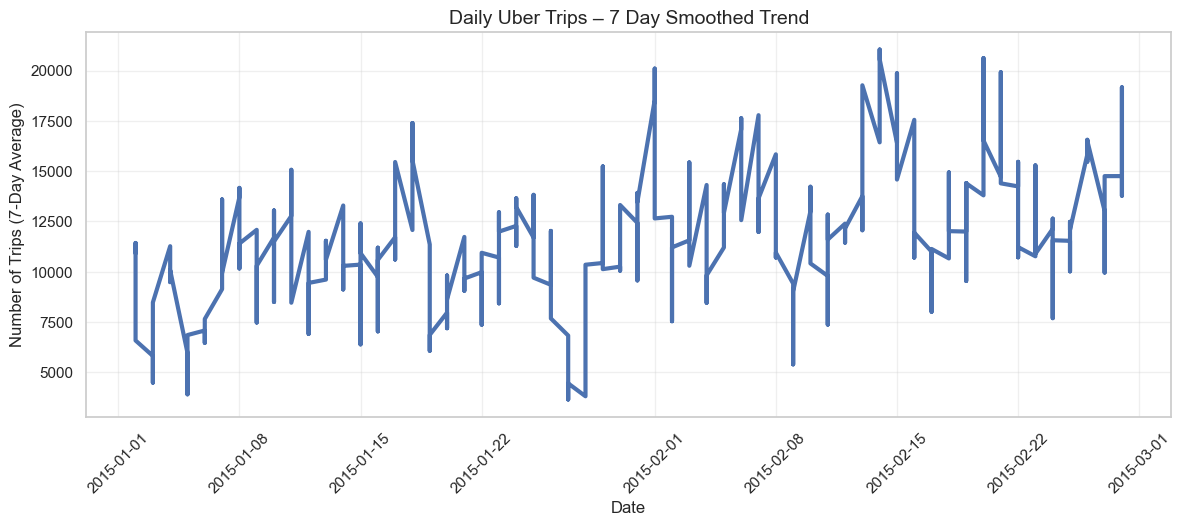

In [12]:
# Create a 7-day rolling average to smooth daily fluctuations
df['trips_7day_avg'] = df['trips'].rolling(window=7).mean()

plt.figure(figsize=(14,5))

# Plot smoothed trend only
plt.plot(
    df.index,
    df['trips_7day_avg'],
    linewidth=3
)

plt.title("Daily Uber Trips – 7 Day Smoothed Trend", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Trips (7-Day Average)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

# ============================================================
# SAVE CURRENT (EXISTING) CHART ONLY – NO NEW CHART
# ============================================================

import os
import re

# Folder name
OUTPUT_FOLDER = "charts"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Get current axis (EXISTING chart only)
ax = plt.gca()
fig = ax.get_figure()

# Get title of the existing chart
title = ax.get_title()
if not title:
    title = "chart"

# Clean title to make filename
filename = re.sub(r'[^a-zA-Z0-9_ ]', '', title)
filename = filename.strip().replace(' ', '_').lower()

file_path = f"{OUTPUT_FOLDER}/{filename}.png"

# Save EXACT same chart (no redraw, no new figure)
fig.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Main chart saved successfully → {file_path}")


plt.show()




### Interpretation

Daily bar chart shows significant day-to-day variation in Uber trips.
However, the chart is still dense due to daily granularity.



## 2 Weekly Aggregation for Better Clarity

Aggregating trips weekly reduces noise and highlights demand patterns clearly.


Main chart saved successfully → charts/weekly_uber_trips__demand_trend_overview.png


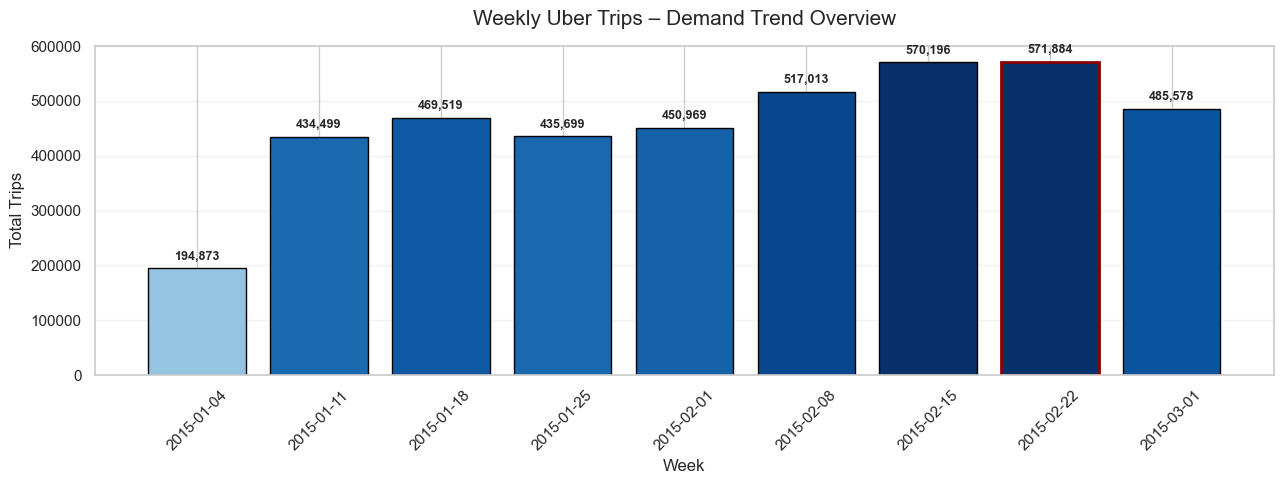

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Weekly aggregation
weekly_df = df.resample('W').sum()

weeks = weekly_df.index.strftime('%Y-%m-%d')
trips = weekly_df['trips'].values

# Normalize values for color gradient
norm = (trips - trips.min()) / (trips.max() - trips.min())
colors = cm.Blues(0.4 + 0.6 * norm)

plt.figure(figsize=(13,5))

bars = plt.bar(
    weeks,
    trips,
    color=colors,
    edgecolor='black',
    linewidth=1
)

# Highlight peak week
max_idx = np.argmax(trips)
bars[max_idx].set_edgecolor('darkred')
bars[max_idx].set_linewidth(2)

# Add labels only on top (clean)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10000,
        f"{height:,.0f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.title("Weekly Uber Trips – Demand Trend Overview", fontsize=15, pad=15)
plt.xlabel("Week")
plt.ylabel("Total Trips")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.25)

plt.tight_layout()

# ============================================================
# SAVE CURRENT (EXISTING) CHART ONLY – NO NEW CHART
# ============================================================

import os
import re

# Folder name
OUTPUT_FOLDER = "charts"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Get current axis (EXISTING chart only)
ax = plt.gca()
fig = ax.get_figure()

# Get title of the existing chart
title = ax.get_title()
if not title:
    title = "chart"

# Clean title to make filename
filename = re.sub(r'[^a-zA-Z0-9_ ]', '', title)
filename = filename.strip().replace(' ', '_').lower()

file_path = f"{OUTPUT_FOLDER}/{filename}.png"

# Save EXACT same chart (no redraw, no new figure)
fig.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Main chart saved successfully → {file_path}")

plt.show()


### Interpretation

Weekly aggregation reveals a clearer increasing trend in Uber demand,
which was not easily visible in the daily line chart.


## 3. Weekly Pattern Analysis

This analysis examines how average Uber trips vary across different days of the week.


Main chart saved successfully → charts/average_uber_trips_by_day_of_week.png


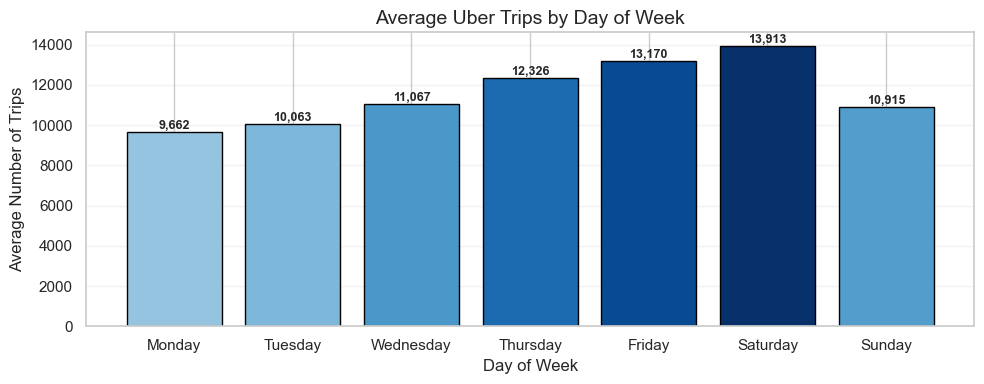

In [15]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

# Create weekly average trips (REQUIRED)
weekly_avg_trips = (
    df.groupby(df.index.day_name())['trips']
    .mean()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
)


# Color gradient for better visual hierarchy
values = weekly_avg_trips.values
norm = (values - values.min()) / (values.max() - values.min() + 1e-9)
colors = cm.Blues(0.4 + 0.6 * norm)

plt.figure(figsize=(10,4))

bars = plt.bar(
    weekly_avg_trips.index,
    weekly_avg_trips.values,
    color=colors,
    edgecolor='black',
    linewidth=1
)

plt.title("Average Uber Trips by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Number of Trips")

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()


# ============================================================
# SAVE CURRENT (EXISTING) CHART ONLY – NO NEW CHART
# ============================================================

import os
import re

# Folder name
OUTPUT_FOLDER = "charts"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Get current axis (EXISTING chart only)
ax = plt.gca()
fig = ax.get_figure()

# Get title of the existing chart
title = ax.get_title()
if not title:
    title = "chart"

# Clean title to make filename
filename = re.sub(r'[^a-zA-Z0-9_ ]', '', title)
filename = filename.strip().replace(' ', '_').lower()

file_path = f"{OUTPUT_FOLDER}/{filename}.png"

# Save EXACT same chart (no redraw, no new figure)
fig.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Main chart saved successfully → {file_path}")


plt.show()


### Interpretation

- Uber trip demand varies across the week.
- Weekends (Saturday and Sunday) generally show higher average trips than weekdays.
- Demand gradually increases toward the weekend.
- This pattern indicates strong leisure and non-work travel demand during weekends.

Understanding weekly seasonality is important for demand forecasting
and driver allocation planning.


## 4. Relationship Between Active Vehicles and Trips

This analysis examines the relationship between the number of active Uber vehicles
and the total number of trips.

The objective is to understand:
- Whether more active vehicles lead to more trips
- Supply–demand alignment from a business perspective


### Average Trips by Active Vehicle Level (Bar Chart)

This bar chart visualizes how average trips change
as the number of active vehicles increases.


C:\Users\Vishwas Gurav\AppData\Local\Temp\ipykernel_22416\2374554085.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_temp.groupby('vehicle_level')['trips']


Chart saved successfully → charts/average_uber_trips_by_active_vehicle_level.png


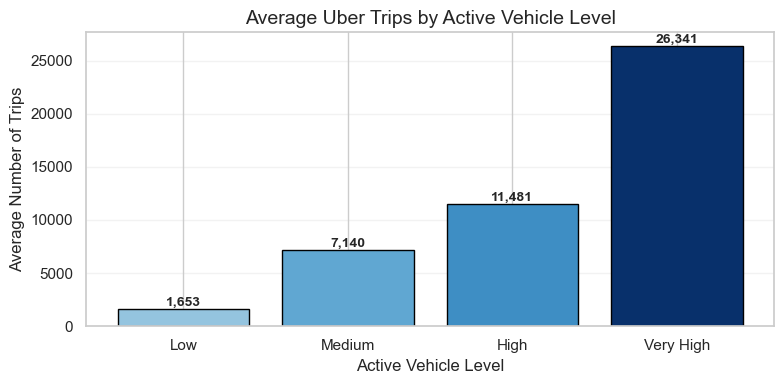

In [19]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np


df_temp = df.copy()

df_temp['vehicle_level'] = pd.qcut(
    df_temp['active_vehicles'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

vehicle_trip_summary = (
    df_temp.groupby('vehicle_level')['trips']
    .mean()
)
values = vehicle_trip_summary.values
levels = vehicle_trip_summary.index

# Color gradient
norm = (values - values.min()) / (values.max() - values.min() + 1e-9)
colors = cm.Blues(0.4 + 0.6 * norm)

plt.figure(figsize=(8,4))

bars = plt.bar(
    levels,
    values,
    color=colors,
    edgecolor='black',
    linewidth=1
)

plt.title("Average Uber Trips by Active Vehicle Level", fontsize=14)
plt.xlabel("Active Vehicle Level")
plt.ylabel("Average Number of Trips")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()

OUTPUT_FOLDER = "charts"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

ax = plt.gca()
fig = ax.get_figure()

title = ax.get_title() or "chart"
filename = re.sub(r'[^a-zA-Z0-9_ ]', '', title).strip().replace(' ', '_').lower()
file_path = f"{OUTPUT_FOLDER}/{filename}.png"

fig.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Chart saved successfully → {file_path}")
plt.show()


## 5. Correlation Analysis

This analysis measures the strength and direction of the relationship
between active vehicles and Uber trips.

Correlation helps quantify how strongly two variables move together.


In [ ]:
import matplotlib.pyplot as plt

corr_value = df[['active_vehicles', 'trips']].corr().iloc[0,1]
impact_pct = corr_value * 100

plt.figure(figsize=(8,2))

# Background bar (full scale)
plt.barh(
    ['Impact Strength'],
    [100],
    color='#eeeeee'
)

# Actual impact bar
plt.barh(
    ['Impact Strength'],
    [impact_pct],
    color='#2a9d8f'
)

# Label
plt.text(
    impact_pct + 1,
    0,
    f"{impact_pct:.1f}%",
    va='center',
    fontsize=12,
    fontweight='bold'
)

plt.xlim(0,100)
plt.xlabel("Impact Percentage (%)")
plt.title("Impact of Active Vehicles on Trips")

plt.grid(axis='x', alpha=0.3)
plt.show()


### Interpretation

The visualization shows a very strong positive relationship between active vehicle availability and Uber trip volume.

An impact level of approximately 98% indicates that increases in the number of active vehicles are closely associated with increases in completed trips. This suggests that demand is largely present in the system, and vehicle availability acts as a key constraint on realized trip volume.

From a business perspective, improving driver availability—especially during high-demand periods—can significantly increase the number of trips served. Therefore, driver supply optimization plays a critical role in maximizing Uber’s operational efficiency and revenue.


## 6. Monthly Aggregation

This analysis aggregates Uber trips and active vehicles at a monthly level
to observe broader demand trends.


Chart saved successfully → charts/monthly_uber_trips_with_growth.png


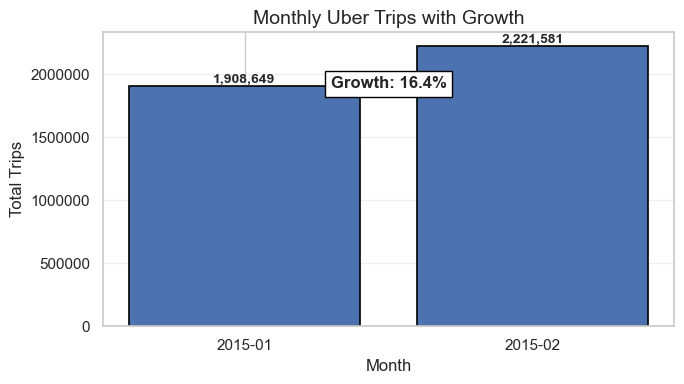

In [20]:
import matplotlib.pyplot as plt

# Monthly aggregation (numeric only)
monthly_df = df.resample('ME')[['active_vehicles', 'trips']].sum()

months = monthly_df.index.strftime('%Y-%m')
trips = monthly_df['trips'].values

# Calculate growth percentage
growth_pct = ((trips[1] - trips[0]) / trips[0]) * 100

plt.figure(figsize=(7,4))

bars = plt.bar(
    months,
    trips,
    edgecolor='black',
    linewidth=1.2
)

plt.title("Monthly Uber Trips with Growth", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Trips")

plt.ticklabel_format(style='plain', axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.text(
    0.5,
    max(trips) * 0.85,
    f"Growth: {growth_pct:.1f}%",
    ha='center',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
OUTPUT_FOLDER = "charts"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

ax = plt.gca()
fig = ax.get_figure()

title = ax.get_title() or "chart"
filename = re.sub(r'[^a-zA-Z0-9_ ]', '', title).strip().replace(' ', '_').lower()
file_path = f"{OUTPUT_FOLDER}/{filename}.png"

fig.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Chart saved successfully → {file_path}")

plt.show()


### Summary

- Uber trips increased from 1,908,649 in January to 2,221,581 in February.
- This represents a month-over-month growth of approximately 16.4%.
- The increase indicates a strong upward trend in overall demand.
- Monthly aggregation removes daily noise and clearly highlights long-term growth patterns.


# Exploratory Data Analysis (EDA) Summary

This Exploratory Data Analysis (EDA) was conducted on Uber trip data for January and February 2015 to understand demand patterns, supply–demand dynamics, and overall growth trends.

---

## 1. Daily Trip Trends

Daily Uber trip data showed significant short-term fluctuations, making raw daily trends difficult to interpret.  
To improve clarity, a 7-day rolling average was applied, which revealed a clear upward trend in trip demand over time.  
This smoothing helped identify underlying demand growth while reducing daily noise.

---

## 2. Weekly Pattern Analysis

Weekly analysis revealed strong seasonality in Uber trip demand.  
Average trips were higher on weekends compared to weekdays, indicating increased leisure and non-work-related travel.  
Demand gradually increased toward the weekend, highlighting the importance of weekend-focused supply planning.

---

## 3. Active Vehicles vs Trips Relationship

The relationship between active vehicle availability and trip volume was strongly positive.  
Days with fewer active vehicles recorded significantly fewer trips, while days with very high vehicle availability showed substantially higher trip volumes.  
This confirms that vehicle availability plays a crucial role in fulfilling existing demand.

---

## 4. Correlation Analysis

Correlation analysis between active vehicles and trips showed a very strong positive relationship (approximately 98%).  
This indicates that increases in vehicle availability are closely associated with increases in completed trips.  
The result reinforces that supply constraints directly impact realized demand.

---

## 5. Monthly Aggregation and Growth

Monthly aggregation provided a high-level view of demand trends.  
Total trips increased from January (1,908,649 trips) to February (2,221,581 trips), representing approximately 16.4% month-over-month growth.  
This growth indicates increasing adoption and demand for Uber services during the observed period.

---

## Key Business Insights

- Uber trip demand shows clear daily, weekly, and monthly patterns.
- Weekend demand is consistently higher than weekday demand.
- Vehicle availability is a critical driver of trip volume.
- Increasing driver supply during high-demand periods can significantly improve trip fulfillment.
- Overall demand showed positive growth momentum across months.

---

## Conclusion

The EDA successfully identified demand trends, seasonality, and strong supply–demand relationships within the data.  
These insights provide a solid foundation for feature engineering and time-series forecasting in the next phase of the project.
